## Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


## Load Data

In [2]:
train_df = pd.read_csv('emnist-byclass-train.csv', nrows=100000)
test_df  = pd.read_csv('emnist-byclass-test.csv',  nrows=20000)

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

print(f"Train shape: {x_train.shape}")
print(f"Test shape:  {x_test.shape}")


Train shape: (80166, 784)
Test shape:  (20000, 784)


## Preprocessing + EMNIST Orientation Fix

In [3]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

x_train = np.flip(np.transpose(x_train, (0, 2, 1, 3)), axis=1)
x_test  = np.flip(np.transpose(x_test,  (0, 2, 1, 3)), axis=1)

num_classes = len(np.unique(y_train))
print(f"Class number: {num_classes}")


Class number: 62


## Sample Visualisation

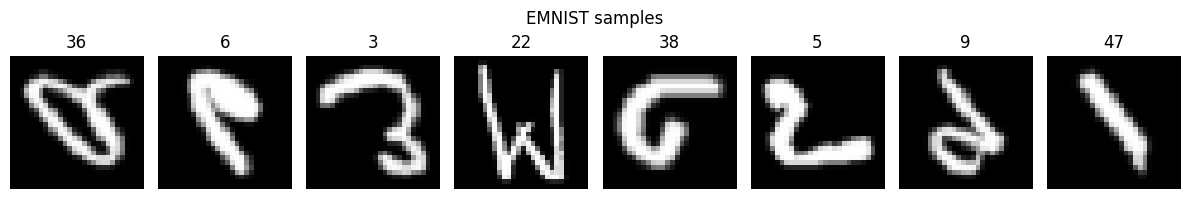

In [5]:
plt.figure(figsize=(12, 2))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle("EMNIST samples")
plt.tight_layout()
plt.show()


## Model Architecture

In [6]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,670 (1.54 MB)

 Trainable params: 404,222 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

## Training

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.6087 - loss: 1.5591 - val_accuracy: 0.0740 - val_loss: nan
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8010 - loss: 0.6043 - val_accuracy: 0.7596 - val_loss: nan
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8269 - loss: 0.5023 - val_accuracy: 0.8462 - val_loss: nan
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8352 - loss: 0.4622 - val_accuracy: 0.8503 - val_loss: nan
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8481 - loss: 0.4231 - val_accuracy: 0.8503 - val_loss: nan
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8534 - loss: 0.4022 - val_accuracy: 0.8489 - val_loss: nan
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8602 - loss: 0.3801 - val_accuracy: 0.8563 - val_loss: nan
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8626 - loss: 0.3634 - val_accuracy: 0.8538 - val_loss: n

##

## Evaluation


Test accuracy: 84.93%


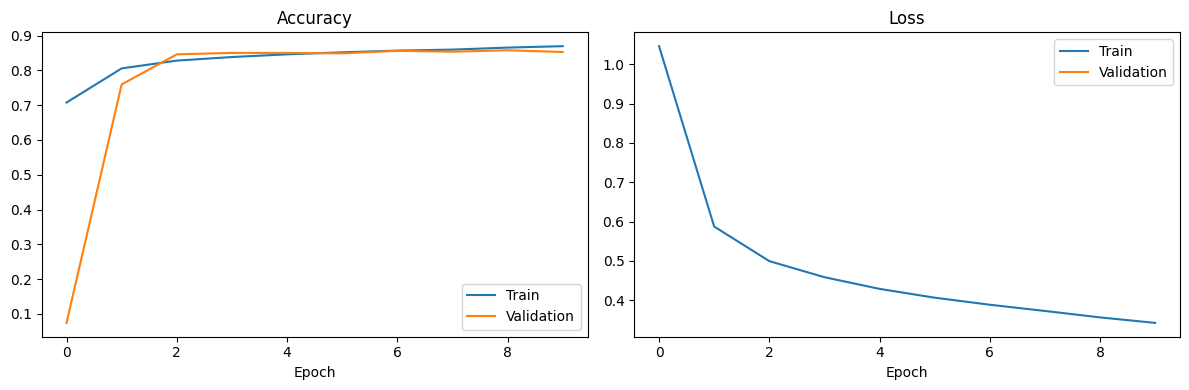

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


## Save Model + Label Mapping

In [11]:
model.save('emnist_model.h5')

rows = []

for i in range(10):
    rows.append({'label': i, 'ascii': 48 + i})

for i in range(26):
    rows.append({'label': 10 + i, 'ascii': 65 + i})

for i in range(26):
    rows.append({'label': 36 + i, 'ascii': 97 + i})

mapping_df = pd.DataFrame(rows)
mapping_df.to_csv('label_mapping.csv', index=False)

print(mapping_df.head(12))


    label  ascii
0       0     48
1       1     49
2       2     50
3       3     51
4       4     52
5       5     53
6       6     54
7       7     55
8       8     56
9       9     57
10     10     65
11     11     66
